# Volatility Surface Calibration

**Interactive Tutorial: SABR Model & Dupire Local Volatility**

This notebook demonstrates:
1. SABR model calibration and implied volatility
2. Dupire local volatility extraction
3. Comparison of native vs QuantLib implementations
4. Visualization of volatility surfaces and smiles

---

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# QuantStrata imports
import sys
sys.path.insert(0, '../..')  # Add project root to path

from src.calibration.volatility_surface import (
    SabrParameters,
    SabrConfig,
    sabr_implied_vol,
    sabr_implied_vol_vec,
    calibrate_sabr_to_smile,
    calibrate_sabr_term_structure,
    create_sabr_vol_surface,
    DupireConfig,
    DupireCalibrator,
    calibrate_local_vol_from_implied,
)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. SABR Model Fundamentals

### 1.1 SABR Dynamics

The SABR model describes forward price dynamics:

$$
\begin{aligned}
dF_t &= \sigma_t F_t^\beta \, dW_t^{(1)} \\
d\sigma_t &= \nu \sigma_t \, dW_t^{(2)} \\
\text{Corr}(dW^{(1)}, dW^{(2)}) &= \rho
\end{aligned}
$$

**Parameters:**
- $\alpha$: Initial volatility level
- $\beta$: CEV exponent (backbone)
- $\rho$: Correlation (skew)
- $\nu$: Vol-of-vol (curvature)

In [2]:
# Create SABR parameters
params = SabrParameters(
    alpha=0.20,   # Initial vol level
    beta=1.0,     # Log-normal (FX convention)
    rho=-0.30,    # Negative skew
    nu=0.50       # Vol-of-vol
)

print("SABR Parameters:")
print(f"  α (alpha) = {params.alpha:.4f} - ATM vol level")
print(f"  β (beta)  = {params.beta:.4f} - CEV exponent")
print(f"  ρ (rho)   = {params.rho:.4f} - Skew direction")
print(f"  ν (nu)    = {params.nu:.4f} - Smile curvature")

SABR Parameters:
  α (alpha) = 0.2000 - ATM vol level
  β (beta)  = 1.0000 - CEV exponent
  ρ (rho)   = -0.3000 - Skew direction
  ν (nu)    = 0.5000 - Smile curvature


### 1.2 SABR Implied Volatility Smile

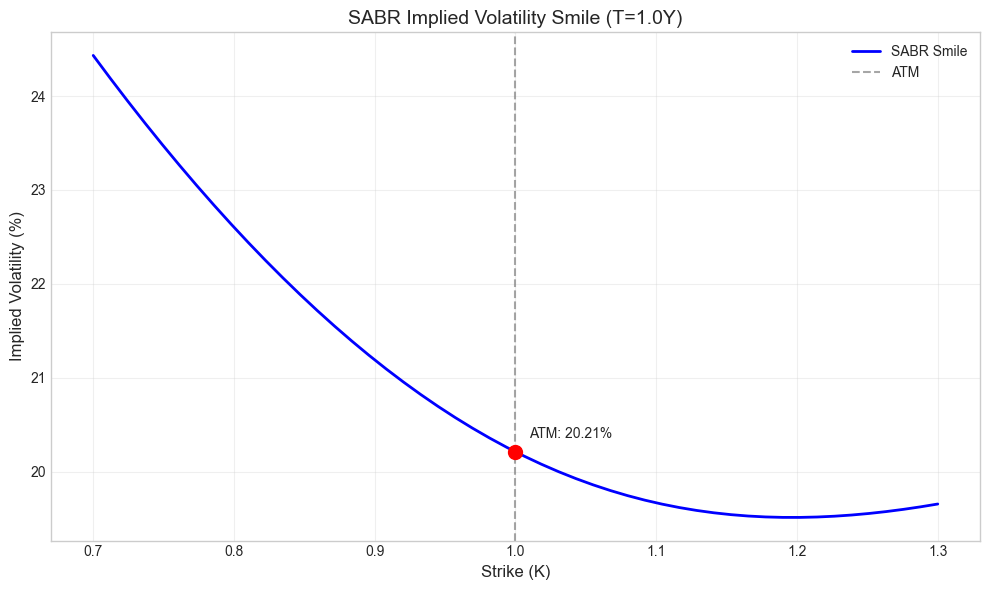

In [3]:
# Market parameters
F = 1.0    # Forward price
T = 1.0    # Expiry (1 year)

# Strike range
strikes = np.linspace(0.70, 1.30, 50)

# Compute SABR implied vols
vols = sabr_implied_vol_vec(forward=F, strikes=strikes, expiry=T, params=params)

# Plot smile
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(strikes, vols * 100, 'b-', linewidth=2, label='SABR Smile')
ax.axvline(F, color='gray', linestyle='--', alpha=0.7, label='ATM')

ax.set_xlabel('Strike (K)', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title(f'SABR Implied Volatility Smile (T={T}Y)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Annotate key points
atm_vol = sabr_implied_vol(forward=F, strike=F, expiry=T, params=params)
ax.scatter([F], [atm_vol * 100], color='red', s=100, zorder=5)
ax.annotate(f'ATM: {atm_vol*100:.2f}%', (F, atm_vol*100), 
            xytext=(10, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

### 1.3 Effect of SABR Parameters

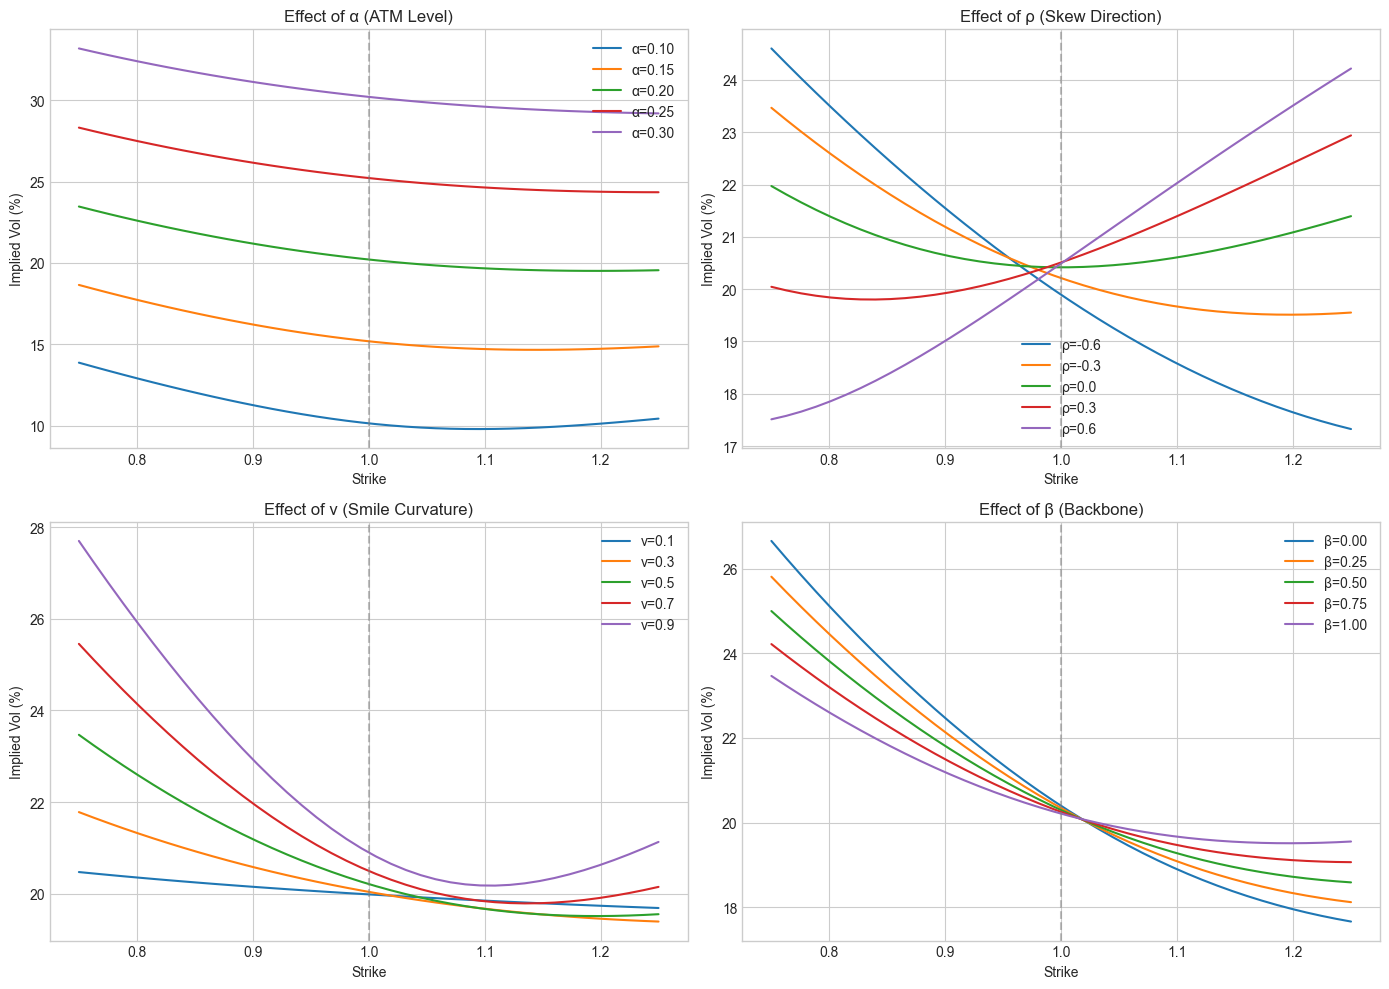

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

strikes = np.linspace(0.75, 1.25, 40)
F, T = 1.0, 1.0

# Effect of alpha (ATM level)
ax = axes[0, 0]
for alpha in [0.10, 0.15, 0.20, 0.25, 0.30]:
    p = SabrParameters(alpha=alpha, beta=1.0, rho=-0.3, nu=0.5)
    vols = sabr_implied_vol_vec(forward=F, strikes=strikes, expiry=T, params=p)
    ax.plot(strikes, vols * 100, label=f'α={alpha:.2f}')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied Vol (%)')
ax.set_title('Effect of α (ATM Level)')
ax.legend()
ax.axvline(F, color='gray', linestyle='--', alpha=0.5)

# Effect of rho (skew)
ax = axes[0, 1]
for rho in [-0.6, -0.3, 0.0, 0.3, 0.6]:
    p = SabrParameters(alpha=0.20, beta=1.0, rho=rho, nu=0.5)
    vols = sabr_implied_vol_vec(forward=F, strikes=strikes, expiry=T, params=p)
    ax.plot(strikes, vols * 100, label=f'ρ={rho:.1f}')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied Vol (%)')
ax.set_title('Effect of ρ (Skew Direction)')
ax.legend()
ax.axvline(F, color='gray', linestyle='--', alpha=0.5)

# Effect of nu (curvature)
ax = axes[1, 0]
for nu in [0.1, 0.3, 0.5, 0.7, 0.9]:
    p = SabrParameters(alpha=0.20, beta=1.0, rho=-0.3, nu=nu)
    vols = sabr_implied_vol_vec(forward=F, strikes=strikes, expiry=T, params=p)
    ax.plot(strikes, vols * 100, label=f'ν={nu:.1f}')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied Vol (%)')
ax.set_title('Effect of ν (Smile Curvature)')
ax.legend()
ax.axvline(F, color='gray', linestyle='--', alpha=0.5)

# Effect of beta (backbone)
ax = axes[1, 1]
for beta in [0.0, 0.25, 0.5, 0.75, 1.0]:
    # Adjust alpha to keep ATM vol similar
    alpha_adj = 0.20 * F**(1-beta)
    p = SabrParameters(alpha=alpha_adj, beta=beta, rho=-0.3, nu=0.5)
    vols = sabr_implied_vol_vec(forward=F, strikes=strikes, expiry=T, params=p)
    ax.plot(strikes, vols * 100, label=f'β={beta:.2f}')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied Vol (%)')
ax.set_title('Effect of β (Backbone)')
ax.legend()
ax.axvline(F, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 2. SABR Calibration

### 2.1 Calibrating to Market Smile

In [5]:
# Generate synthetic "market" data with known parameters
true_params = SabrParameters(alpha=0.22, beta=1.0, rho=-0.35, nu=0.55)

F = 1.0
T = 1.0
market_strikes = np.array([0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15])

# Generate "market" vols with small noise
np.random.seed(42)
market_vols = sabr_implied_vol_vec(forward=F, strikes=market_strikes, expiry=T, params=true_params)
market_vols_noisy = market_vols + np.random.normal(0, 0.002, size=market_vols.shape)  # 20bp noise

print("Market Quotes (with noise):")
print(f"{'Strike':>8} {'Vol (%)':>10}")
print("-" * 20)
for k, v in zip(market_strikes, market_vols_noisy):
    print(f"{k:8.2f} {v*100:10.2f}")

Market Quotes (with noise):
  Strike    Vol (%)
--------------------
    0.85      24.30
    0.90      23.40
    0.95      22.89
    1.00      22.52
    1.05      21.75
    1.10      21.44
    1.15      21.60


In [6]:
# Calibrate SABR to market
config = SabrConfig(beta=1.0)  # Fix beta

calibrated = calibrate_sabr_to_smile(
    forward=F,
    strikes=market_strikes,
    market_vols=market_vols_noisy,
    expiry=T,
    config=config,
)

print("\nCalibration Results:")
print(f"{'Parameter':>10} {'True':>10} {'Calibrated':>12} {'Error':>10}")
print("-" * 45)
print(f"{'α':>10} {true_params.alpha:10.4f} {calibrated.alpha:12.4f} {abs(calibrated.alpha - true_params.alpha):10.4f}")
print(f"{'β':>10} {true_params.beta:10.4f} {calibrated.beta:12.4f} {'(fixed)':>10}")
print(f"{'ρ':>10} {true_params.rho:10.4f} {calibrated.rho:12.4f} {abs(calibrated.rho - true_params.rho):10.4f}")
print(f"{'ν':>10} {true_params.nu:10.4f} {calibrated.nu:12.4f} {abs(calibrated.nu - true_params.nu):10.4f}")


Calibration Results:
 Parameter       True   Calibrated      Error
---------------------------------------------
         α     0.2200       0.2196     0.0004
         β     1.0000       1.0000    (fixed)
         ρ    -0.3500      -0.3120     0.0380
         ν     0.5500       0.5935     0.0435


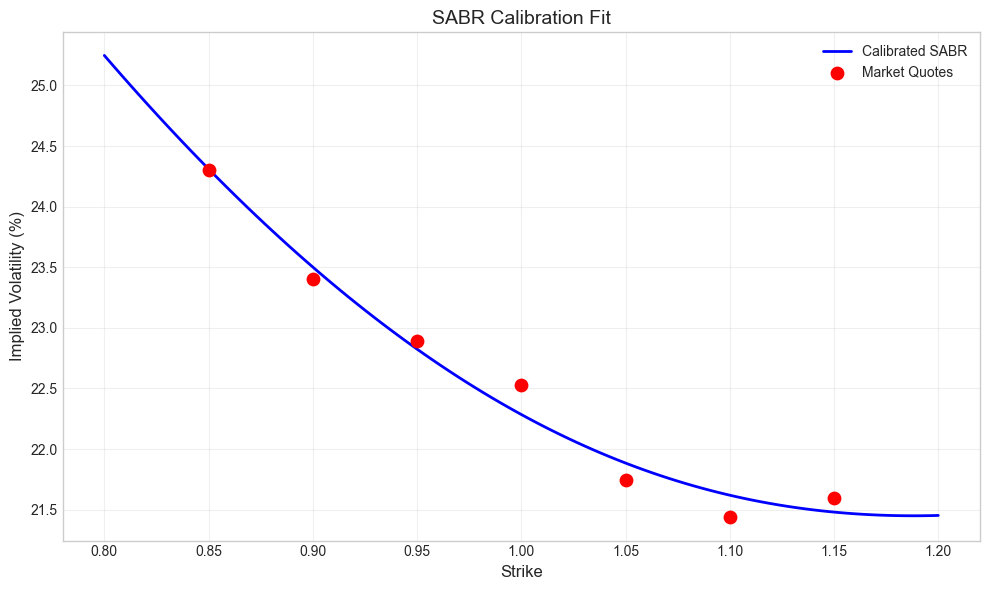


Fit Quality: RMSE = 14.10 bp


In [7]:
# Plot calibration fit
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Fine strike grid for smooth curve
strikes_fine = np.linspace(0.80, 1.20, 100)
vols_calibrated = sabr_implied_vol_vec(forward=F, strikes=strikes_fine, expiry=T, params=calibrated)

# Plot
ax.plot(strikes_fine, vols_calibrated * 100, 'b-', linewidth=2, label='Calibrated SABR')
ax.scatter(market_strikes, market_vols_noisy * 100, color='red', s=80, zorder=5, label='Market Quotes')

ax.set_xlabel('Strike', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title('SABR Calibration Fit', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute fit quality
fitted_at_quotes = sabr_implied_vol_vec(forward=F, strikes=market_strikes, expiry=T, params=calibrated)
rmse = np.sqrt(np.mean((fitted_at_quotes - market_vols_noisy)**2)) * 100 * 100  # in bp
print(f"\nFit Quality: RMSE = {rmse:.2f} bp")

### 2.2 Term Structure Calibration

In [8]:
# Generate term structure data
expiries = [0.25, 0.5, 1.0, 2.0]
F_by_T = {T: 1.0 for T in expiries}
K_by_T = {T: np.array([0.85, 0.90, 0.95, 1.0, 1.05, 1.10, 1.15]) for T in expiries}

# Different "true" params for each expiry (vol term structure)
true_params_by_T = {
    0.25: SabrParameters(alpha=0.24, beta=1.0, rho=-0.40, nu=0.60),
    0.50: SabrParameters(alpha=0.22, beta=1.0, rho=-0.35, nu=0.55),
    1.00: SabrParameters(alpha=0.20, beta=1.0, rho=-0.30, nu=0.50),
    2.00: SabrParameters(alpha=0.18, beta=1.0, rho=-0.25, nu=0.45),
}

# Generate "market" vols
vols_by_T = {
    T: sabr_implied_vol_vec(forward=F_by_T[T], strikes=K_by_T[T], expiry=T, params=true_params_by_T[T])
    for T in expiries
}

# Calibrate term structure
params_by_T = calibrate_sabr_term_structure(
    forward_by_expiry=F_by_T,
    strikes_by_expiry=K_by_T,
    vols_by_expiry=vols_by_T,
    config=SabrConfig(beta=1.0),
)

# Display results
print("Calibrated SABR Term Structure:")
print(f"{'Expiry':>8} {'α':>8} {'ρ':>8} {'ν':>8}")
print("-" * 35)
for T, p in sorted(params_by_T.items()):
    print(f"{T:8.2f} {p.alpha:8.4f} {p.rho:8.4f} {p.nu:8.4f}")

Calibrated SABR Term Structure:
  Expiry        α        ρ        ν
-----------------------------------
    0.25   0.2410  -0.4535   0.5286
    0.50   0.2212  -0.4003   0.4841
    1.00   0.2015  -0.3460   0.4388
    2.00   0.1816  -0.3462   0.4383


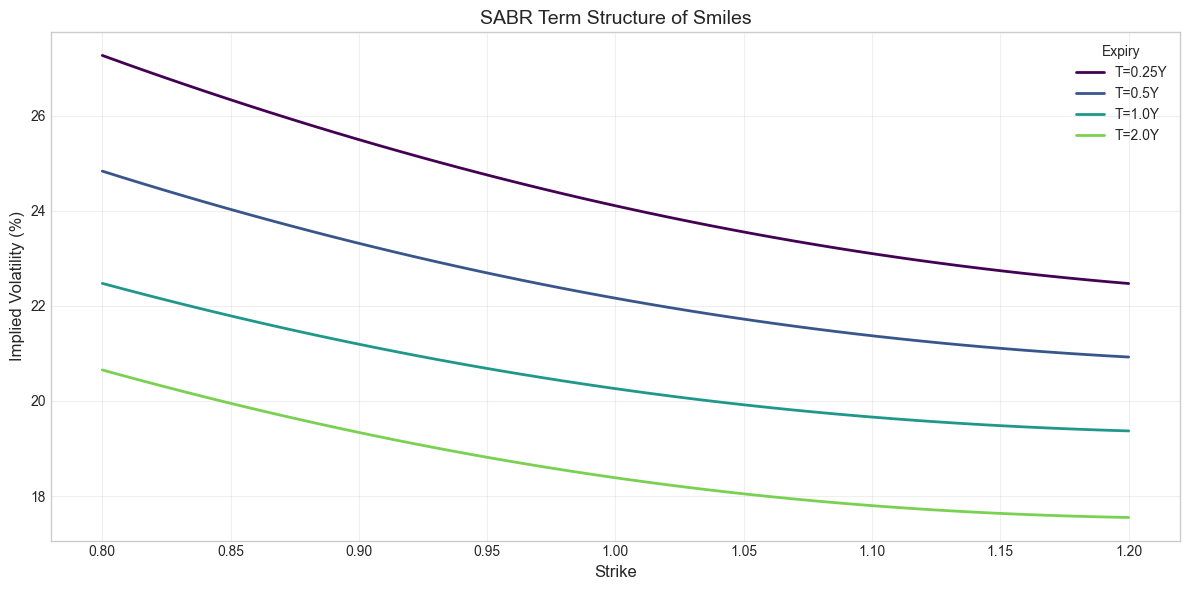

In [9]:
# Plot term structure of smiles
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

strikes_fine = np.linspace(0.80, 1.20, 50)
colors = plt.cm.viridis(np.linspace(0, 0.8, len(expiries)))

for T, color in zip(expiries, colors):
    vols = sabr_implied_vol_vec(forward=1.0, strikes=strikes_fine, expiry=T, params=params_by_T[T])
    ax.plot(strikes_fine, vols * 100, color=color, linewidth=2, label=f'T={T}Y')

ax.set_xlabel('Strike', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title('SABR Term Structure of Smiles', fontsize=14)
ax.legend(title='Expiry')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Dupire Local Volatility

### 3.1 Local Vol from Flat Implied Vol

**Key Result:** If implied vol is flat ($\sigma_{BS} = const$), then local vol equals implied vol.

In [10]:
# Create a flat implied vol surface
class FlatVolSurface:
    """Simple flat vol surface for testing."""
    def __init__(self, sigma: float):
        self.sigma = sigma
    
    def implied_vol(self, expiry: float, strike: float) -> float:
        return self.sigma

flat_surface = FlatVolSurface(sigma=0.20)

# Calibrate local vol
spot = 100.0
r, q = 0.05, 0.02

local_vol_surface = calibrate_local_vol_from_implied(
    implied_surface=flat_surface,
    spot=spot,
    r=r,
    q=q,
)

# Check that local vol ≈ implied vol
print("Flat Implied Vol Test:")
print(f"Implied Vol: {flat_surface.sigma:.2%}")
print(f"Local Vol (ATM, T=0.5): {local_vol_surface.local_vol(spot=spot, time=0.5):.2%}")
print(f"Local Vol (ATM, T=1.0): {local_vol_surface.local_vol(spot=spot, time=1.0):.2%}")

Flat Implied Vol Test:
Implied Vol: 20.00%
Local Vol (ATM, T=0.5): 19.98%
Local Vol (ATM, T=1.0): 19.99%


### 3.2 Local Vol from Smile Surface

In [11]:
# Create a SABR-based implied vol surface
class SabrImpliedVolSurface:
    """Implied vol surface using SABR model."""
    def __init__(self, params_by_expiry, forward_by_expiry):
        self.params_by_expiry = params_by_expiry
        self.forward_by_expiry = forward_by_expiry
        self._vol_func = create_sabr_vol_surface(
            params_by_expiry=params_by_expiry,
            forward_by_expiry=forward_by_expiry,
            strikes=np.linspace(0.5, 1.5, 50),
        )
    
    def implied_vol(self, expiry: float, strike: float) -> float:
        # Convert strike to moneyness relative to spot=100
        return self._vol_func(expiry, strike / 100.0)

# Use earlier calibrated SABR params
sabr_surface = SabrImpliedVolSurface(
    params_by_expiry=params_by_T,
    forward_by_expiry=F_by_T,
)

# Calibrate local vol
local_vol_from_sabr = calibrate_local_vol_from_implied(
    implied_surface=sabr_surface,
    spot=100.0,
    r=0.05,
    q=0.02,
    times=np.array([0.1, 0.25, 0.5, 1.0]),
    spots=np.linspace(70, 130, 15),
)

print(f"Local Vol Surface Shape: {local_vol_from_sabr.shape}")

Local Vol Surface Shape: (4, 15)


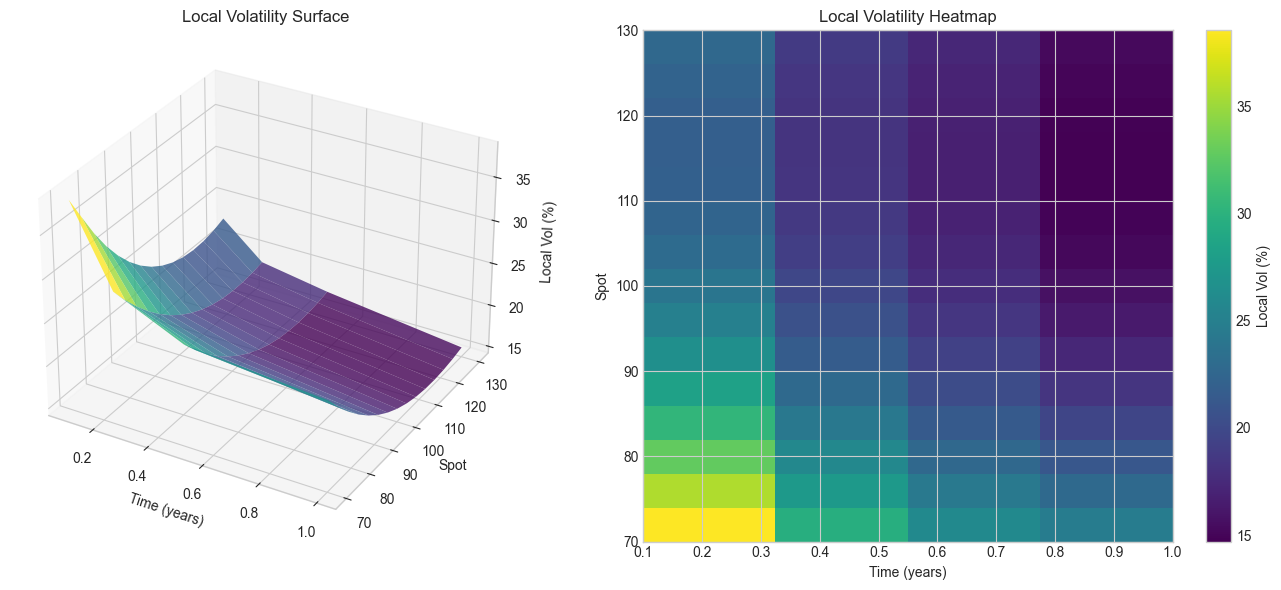

In [12]:
# Visualize Local Vol Surface (3D)
fig = plt.figure(figsize=(14, 6))

# 3D Surface
ax1 = fig.add_subplot(121, projection='3d')

T_grid, S_grid = np.meshgrid(local_vol_from_sabr.times, local_vol_from_sabr.spots)
LV_grid = local_vol_from_sabr.local_vols.T * 100  # Convert to %

surf = ax1.plot_surface(T_grid, S_grid, LV_grid, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Spot')
ax1.set_zlabel('Local Vol (%)')
ax1.set_title('Local Volatility Surface')

# 2D Heatmap
ax2 = fig.add_subplot(122)
im = ax2.imshow(
    local_vol_from_sabr.local_vols.T * 100,
    aspect='auto',
    origin='lower',
    extent=[local_vol_from_sabr.times.min(), local_vol_from_sabr.times.max(),
            local_vol_from_sabr.spots.min(), local_vol_from_sabr.spots.max()],
    cmap='viridis',
)
ax2.set_xlabel('Time (years)')
ax2.set_ylabel('Spot')
ax2.set_title('Local Volatility Heatmap')
plt.colorbar(im, ax=ax2, label='Local Vol (%)')

plt.tight_layout()
plt.show()

### 3.3 Local Vol vs Implied Vol Relationship

**Key Insight:** Local vol is generally **higher** than implied vol at the wings (OTM options).

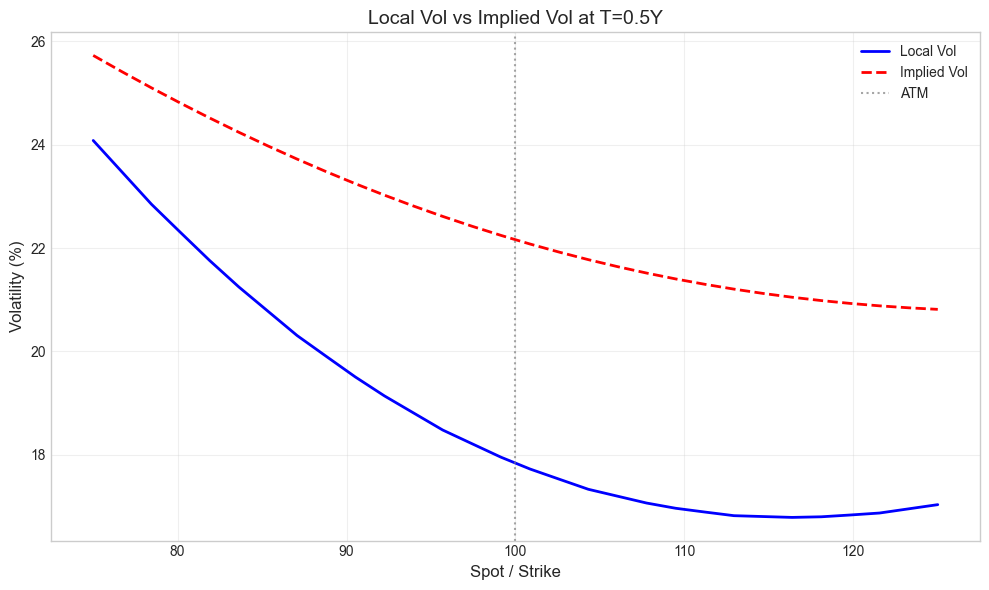

In [13]:
# Compare local vol vs implied vol at T=0.5
T_compare = 0.5
spots_compare = np.linspace(75, 125, 30)

local_vols = np.array([local_vol_from_sabr.local_vol(spot=s, time=T_compare) for s in spots_compare])
implied_vols = np.array([sabr_surface.implied_vol(T_compare, s) for s in spots_compare])

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(spots_compare, local_vols * 100, 'b-', linewidth=2, label='Local Vol')
ax.plot(spots_compare, implied_vols * 100, 'r--', linewidth=2, label='Implied Vol')
ax.axvline(100, color='gray', linestyle=':', alpha=0.7, label='ATM')

ax.set_xlabel('Spot / Strike', fontsize=12)
ax.set_ylabel('Volatility (%)', fontsize=12)
ax.set_title(f'Local Vol vs Implied Vol at T={T_compare}Y', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Summary and Key Takeaways

### SABR Model
- **Use case**: Smile interpolation and extrapolation
- **Parameters**: α (level), β (backbone, usually fixed), ρ (skew), ν (curvature)
- **Calibration**: Typically fix β, optimize (α, ρ, ν)

### Dupire Local Vol
- **Use case**: Full surface calibration, exotic pricing
- **Formula**: Extract local vol from call prices/implied vols
- **Key result**: Local vol ≥ implied vol at wings

### Interview Tips
1. Know the SABR parameter effects
2. Understand why β is fixed
3. Know Dupire's formula and its derivation
4. Understand the relationship between local and implied vol